In [1]:
# Skipped in CI: Colab/bootstrap dependency install cell.


# ノイズ生成: 基本

**目的**: **GWexpy** を使用して重力波データのノイズを生成・操作・モデル化する方法を学びます。

**前提条件**:
- `pygwinc`（オプション、検出器モデル用）
- `obspy`（オプション、地震モデル用）

## 1. ASD（振幅スペクトル密度）の生成

GWexpy は、理論的なべき乗則から検出器固有モデルまで、ASD を生成するいくつかの方法を提供します。

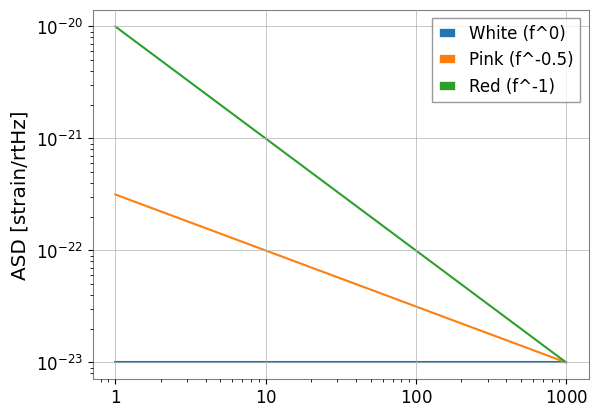

In [2]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import numpy as np

from gwexpy.noise import asd

freqs = np.logspace(0, 3, 1000)

# 1. Power-law ASDs
white = asd.white_noise(amplitude=1e-23, frequencies=freqs)
pink = asd.pink_noise(amplitude=1e-22, f_ref=10, frequencies=freqs)
red = asd.red_noise(amplitude=1e-21, f_ref=10, frequencies=freqs)

plt.loglog(white.xindex, white, label="White (f^0)")
plt.loglog(pink.xindex, pink, label="Pink (f^-0.5)")
plt.loglog(red.xindex, red, label="Red (f^-1)")
plt.ylabel("ASD [strain/rtHz]")
plt.legend()
plt.show()

## 2. 時間領域ノイズの生成

`gwexpy.noise.wave` を使用して、時間領域でカラードノイズを直接生成できます。

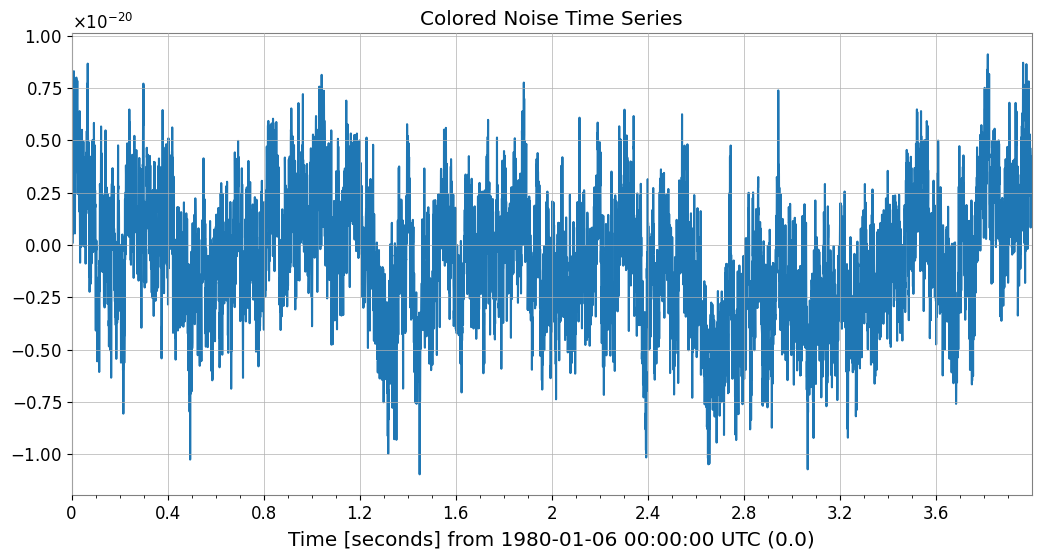

In [3]:
from gwexpy.noise import wave

duration = 4.0
fs = 2048

# Generate pink noise time series
noise_ts = wave.pink_noise(duration=duration, sample_rate=fs, amplitude=1e-21)

noise_ts.plot()
plt.title("Colored Noise Time Series")
plt.show()

## 3. スペクトル線とマスキング

実際のノイズには狭帯域の共鳴ピーク（スペクトル線）が含まれます。ローレンツ型またはガウス型の形状で追加できます。

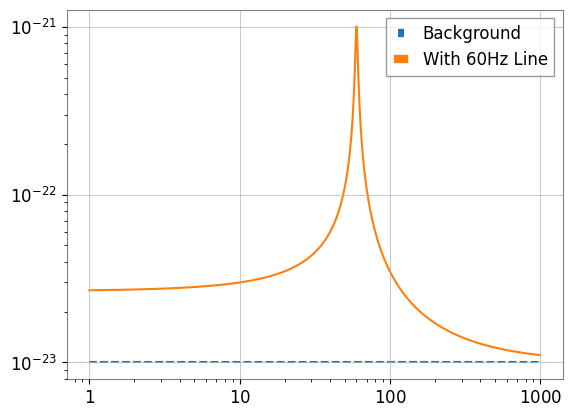

In [4]:
from gwexpy.noise.asd import lorentzian_line

# lorentzian_line requires Q or gamma (HWHM)
line = lorentzian_line(f0=60, gamma=1.0, amplitude=1e-21, frequencies=freqs)
total_asd = white + line

plt.loglog(freqs, white.value, "--", label="Background")
plt.loglog(freqs, total_asd.value, label="With 60Hz Line")
plt.legend()
plt.show()

## 4. 非ガウスノイズ（グリッチ）

`gwexpy.noise.non_gaussian` は、散乱光や過渡バーストなどの非定常ノイズのモデルを提供します。

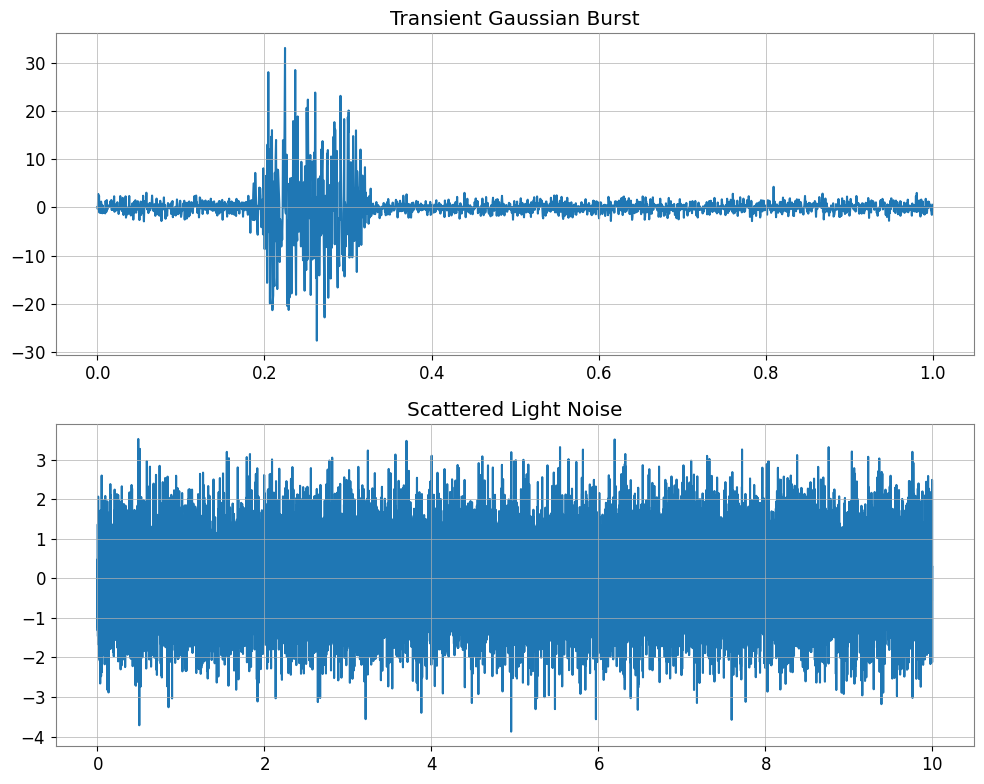

In [5]:
from gwexpy.noise.non_gaussian import scatter_light_noise, transient_gaussian_noise

# 1. Transient burst (Model I)
burst = transient_gaussian_noise(duration=1.0, sample_rate=fs, A1=10.0)

# 2. Scattered light (Model II)
scatter = scatter_light_noise(duration=10.0, sample_rate=fs, A2=1e-6, G=1e-21)

fig, ax = plt.subplots(2, 1, figsize=(10, 8))
ax[0].plot(burst.times, burst); ax[0].set_title("Transient Gaussian Burst")
ax[1].plot(scatter.times, scatter); ax[1].set_title("Scattered Light Noise")
plt.tight_layout()
plt.show()

## 5. ケーススタディ：簡単なノイズバジェット

複数のノイズ源（地震、熱、ショットノイズ）を組み合わせて、合計ノイズバジェットを作成します。

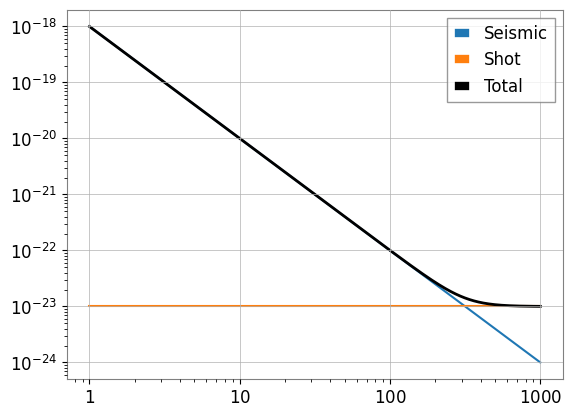

In [6]:
# seismic ~ f^-2
seismic = asd.power_law(exponent=2, amplitude=1e-20, f_ref=10, frequencies=freqs)
# shot ~ f^0
shot = asd.white_noise(amplitude=1e-23, frequencies=freqs)

total = np.sqrt(seismic.value**2 + shot.value**2)

plt.loglog(freqs, seismic.value, label="Seismic")
plt.loglog(freqs, shot.value, label="Shot")
plt.loglog(freqs, total, "k", lw=2, label="Total")
plt.legend()
plt.show()

## よくある落とし穴と失敗モード

- **ASD の傾きだけで時間領域ノイズが妥当だと判断すること**: 目標スペクトルに平均的には合っていても、有限長の分散、線構造、過渡成分は別の挙動を示すことがあります。
- **別々に生成した成分をそのまま独立な物理源だと読むこと**: 地震・熱・ショットノイズを合成した合計曲線は、数値モデルの例であり、実機で同じ分離が観測的に確立していることを意味しません。
- **スペクトル線の高さと幅を混同すること**: 狭線では `Q` や `gamma` の変更は、単純な振幅変更とは別の解釈を持ちます。
- **グリッチ例を実環境の発生分布だと思うこと**: 非ガウスノイズの例は形状とワークフローを示すためのもので、実際の発生率や装置環境を校正したモデルではありません。
- **単位や基準周波数を確認せずに曲線を比較すること**: 見た目がもっともらしくても、`amplitude`、`exponent`、`f_ref` の意味づけを誤ると解釈は崩れます。
- **簡易ノイズバジェットを検証済みの装置バジェットだと扱うこと**: このケーススタディは合成方法の説明であり、結合測定や不確かさ評価を含む検証済みバジェットの代替ではありません。


## 6. 演習

1. **スペクトルから時系列へ**: `wave.colored` を使って指数 1.5、10秒間の信号を生成し、ASD をプロットして傾きを確認してください。
2. **スペクトル線除去**（発展）: セクション 3 で追加した 60Hz 線を除去してみてください。

## 7. 検証セル（NBMAKE）

自動 CI 検証に使用します。

In [7]:
assert len(white) == 1000
assert noise_ts.sample_rate.value == 2048
print("Validation successful!")

Validation successful!
